In [3]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

from scipy import stats
# from matplotlib.colors import LogNorm
import mpl_scatter_density
from astropy.visualization.mpl_normalize import ImageNormalize
from IPython.display import Image

In [4]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [5]:
target_dir_dr8 = '/Volumes/Samsung T5/tmp/dr8'
target_dir_dr9 = '/Volumes/Samsung T5/tmp/dr9m-sep26-2020'
data_dir = '/Volumes/Samsung T5/tmp/dr9_tests'

target_class = 'ELG'

target_path_list = glob.glob(os.path.join(target_dir_dr9, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
# target_path_list_dr8 = glob.glob(os.path.join(target_dir_dr8, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
target_path_list_dr8 = glob.glob(os.path.join(target_dir_dr8, '0.42.0/targets/main/resolve/dark/targets-dark-hp-*.fits'))
print(len(target_path_list), len(target_path_list_dr8))

target_bits = {'LRG':0, 'ELG':1, 'QSO':2, 'BGS_ANY':60}
target_bit = target_bits[target_class]
target_columns = ['BRICKID', 'BRICK_OBJID', 'MORPHTYPE', 'RA', 'DEC', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FLUX_W1', 'FLUX_W2', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'WISEMASK_W1', 'WISEMASK_W2', 'MASKBITS', 'PHOTSYS', 'DESI_TARGET']

37 41


-------
# North
---------

In [4]:
field = 'north'
if field=='south':
    region = 'S'
else:
    region = 'N'

In [5]:
cat = []
for target_path in target_path_list:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    cat.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
cat = vstack(cat)
print(len(cat))

/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
0.5964338305149155 301347 505248
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
0.5973626583293945 688792 1153055
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-18.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/r

In [6]:
dr8 = []
for target_path in target_path_list_dr8:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    dr8.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
dr8 = vstack(dr8)
print(len(dr8))

/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
0.595443132932225 311150 522552
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
0.5933346112351316 699551 1179016
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-38.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-18.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-34.fits


In [7]:
print(len(cat))
print(len(dr8))
print(len(dr8)/len(cat))

11738729
12726155
1.0841169431545783


In [8]:
cat.write(os.path.join(data_dir, '{}_dr9m_{}.fits'.format(target_class, field)))
dr8.write(os.path.join(data_dir, '{}_dr8_{}.fits'.format(target_class, field)))

---------

In [16]:
field = 'north'
cat = Table.read(os.path.join(data_dir, '{}_dr9m_{}.fits'.format(target_class, field)))
dr8 = Table.read(os.path.join(data_dir, '{}_dr8_{}.fits'.format(target_class, field)))

In [19]:
norm = ImageNormalize(vmin=0., vmax=50)

fig = plt.figure(figsize=(25, 12.5))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'], cat['DEC'], color='C0', norm=norm)
ax.axis([310, 80, 30, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/tmp_{}_{}_dr9.png'.format(target_class, field))
plt.close()

fig = plt.figure(figsize=(25, 12.5))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(dr8['RA'], dr8['DEC'], color='C0', norm=norm)
ax.axis([310, 80, 30, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/tmp_{}_{}_dr8.png'.format(target_class, field))
plt.close()

In [11]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(cat['RA'], cat['DEC'], dr8['RA'], dr8['DEC'], search_radius=0.1, plot_q=False)
print(len(idx1)/len(cat))
print(len(idx2)/len(dr8))

cat_missing = cat[~np.in1d(np.arange(len(cat)), idx1)]
dr8_missing = dr8[~np.in1d(np.arange(len(dr8)), idx2)]
cat = cat[idx1]
dr8 = dr8[idx2]

print(len(cat_missing)+len(cat))
print(len(dr8_missing)+len(dr8))

Doubly matched objects = 52
Final matched objects = 7665699
0.6530263199704158
0.6023578213529538
11738729
12726155


In [12]:
cat_missing.write(os.path.join(data_dir, '{}_no_match_dr9m_{}.fits'.format(target_class, field)))
dr8_missing.write(os.path.join(data_dir, '{}_no_match_dr8_{}.fits'.format(target_class, field)))
cat.write(os.path.join(data_dir, '{}_matched_dr9m_{}.fits'.format(target_class, field)))
dr8.write(os.path.join(data_dir, '{}_matched_dr8_{}.fits'.format(target_class, field)))

------

In [5]:
field = 'north'
cat = Table.read(os.path.join(data_dir, '{}_matched_dr9m_{}.fits'.format(target_class, field)))
dr8 = Table.read(os.path.join(data_dir, '{}_matched_dr8_{}.fits'.format(target_class, field)))

In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    dr8['gmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_G']/dr8['MW_TRANSMISSION_G'])
    dr8['rmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_R']/dr8['MW_TRANSMISSION_R'])
    dr8['zmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_Z']/dr8['MW_TRANSMISSION_Z'])
    dr8['w1mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W1']/dr8['MW_TRANSMISSION_W1'])
    dr8['w2mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W2']/dr8['MW_TRANSMISSION_W2'])

In [7]:
t = Table()
t['type'], t['counts'] = np.unique(dr8['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(dr8)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR8')
print(t)
print()

t = Table()
t['type'], t['counts'] = np.unique(cat['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(cat)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR9')
print(t)

DR8
type  counts frac (%)
---- ------- --------
COMP     610      0.0
 DEV  135722      1.8
 EXP  375318      4.9
 PSF 1167254     15.2
 REX 5986795     78.1

DR9
type  counts frac (%)
---- ------- --------
 SER    2412      0.0
 DEV  111886      1.5
 EXP  377420      4.9
 PSF 1350875     17.6
 REX 5823106     76.0


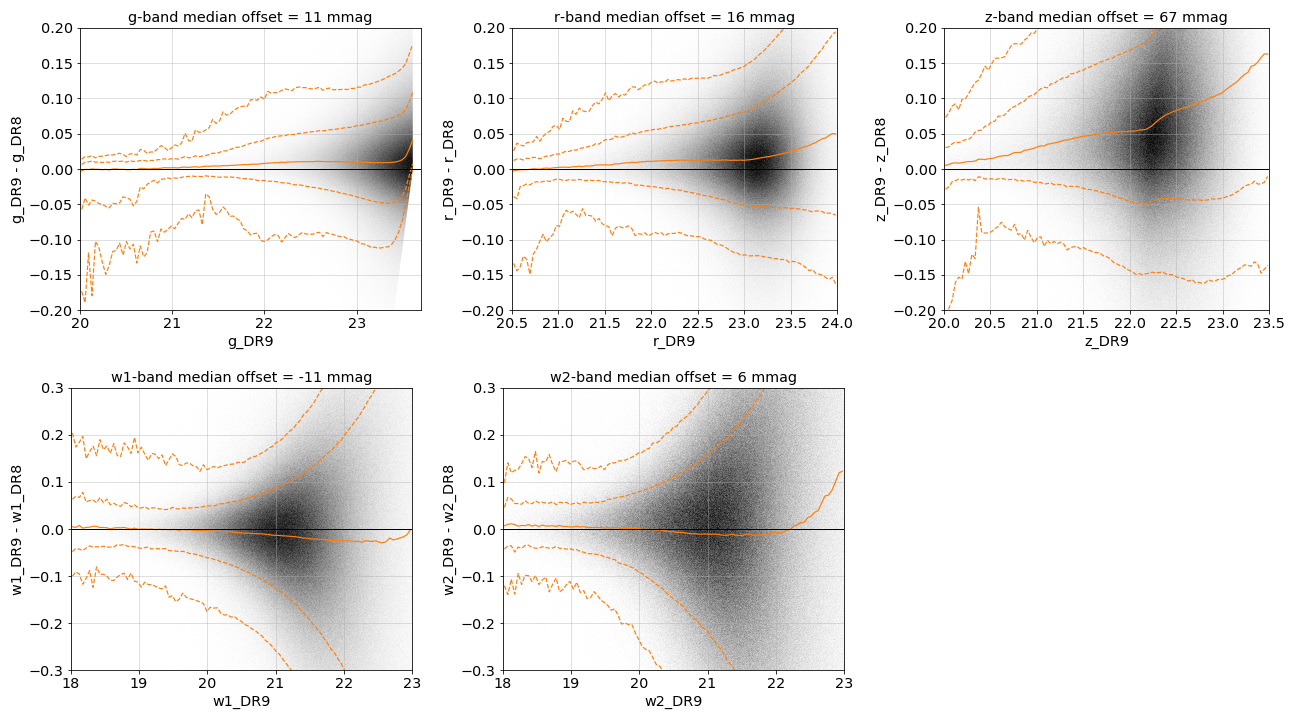

In [8]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[20, 23.7], [20.5, 24], [20, 23.5], [18, 23], [18, 23]]
ylims = [[-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.3, 0.3], [-0.3, 0.3]]
for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = np.isfinite(v)
    median_offset = np.median(v[mask])
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')

__Look at the bright end__

/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in greater
  result = getattr(super(), op)(other)
/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in less
  result = getattr(super(), op)(other)
/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in greater
  result = getattr(super(), op)(other)
/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in less
  result = getattr(super(), op)(other)


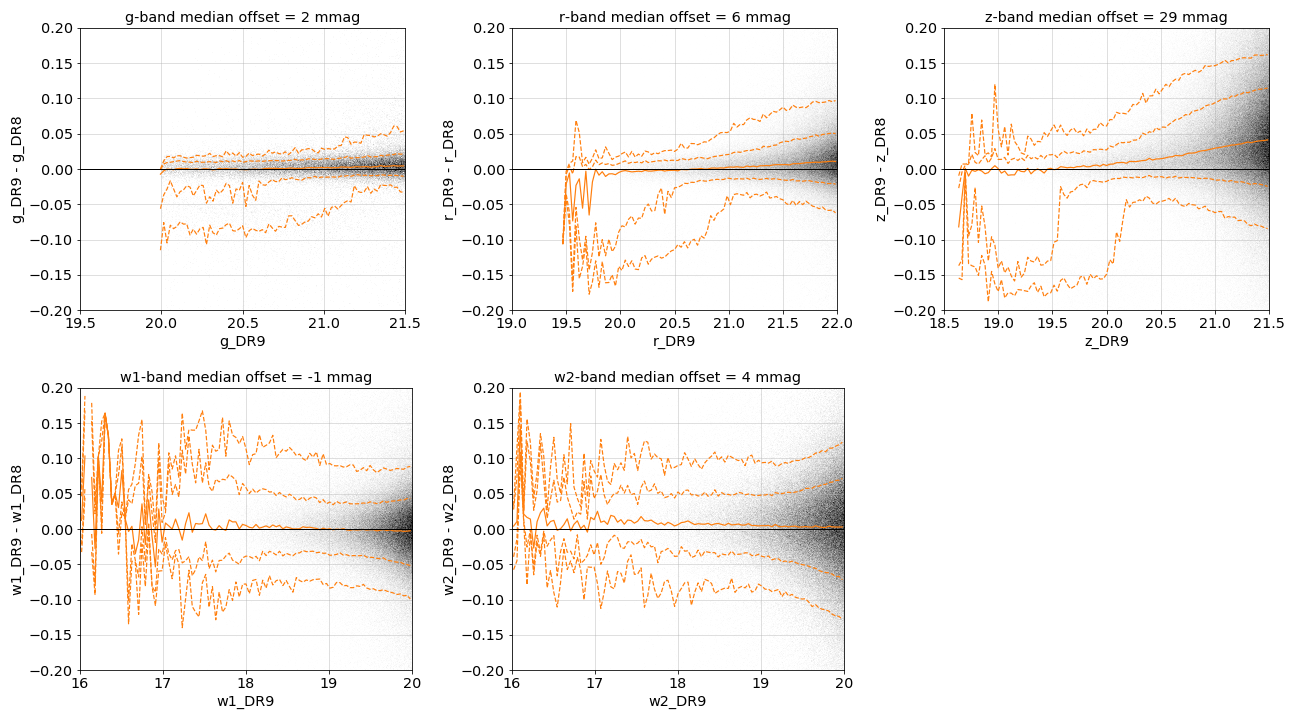

In [9]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[19.5, 21.5], [19., 22], [18.5, 21.5], [16, 20], [16, 20]]
ylims = [[-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2]]
for index in range(len(col_list)):
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = np.isfinite(v)
    mask &= (cat[col]>xmin) & (cat[col]<xmax) & (v>ymin) & (v<ymax)
    median_offset = np.median(v[mask])
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')

__REX objects (in both) only__

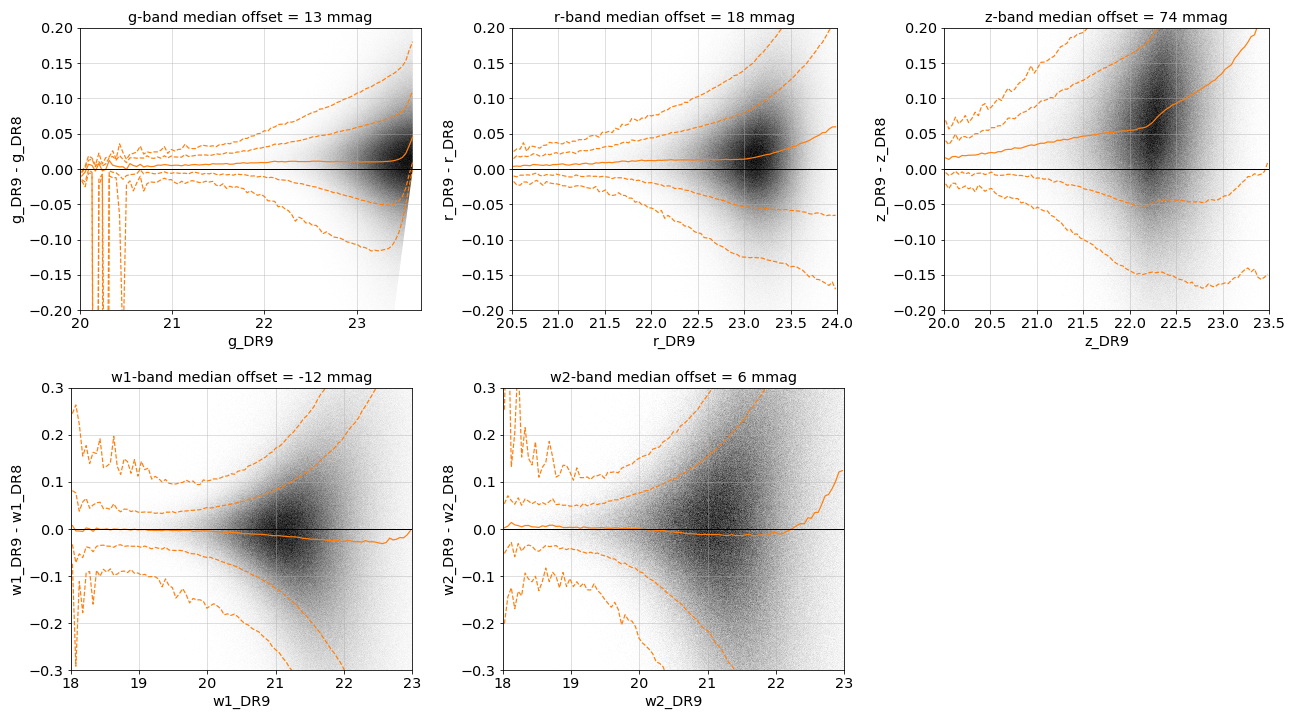

In [10]:
mask0 = (dr8['MORPHTYPE']=='REX') & (cat['MORPHTYPE']=='REX')

col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[20, 23.7], [20.5, 24], [20, 23.5], [18, 23], [18, 23]]
ylims = [[-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.3, 0.3], [-0.3, 0.3]]
for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = mask0 & (np.isfinite(v))
    median_offset = np.median(v[mask])
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')

-------
# South
---------

In [11]:
field = 'south'
if field=='south':
    region = 'S'
else:
    region = 'N'

In [9]:
cat = []
for target_path in target_path_list:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    cat.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
cat = vstack(cat)
print(len(cat))

/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
0.6104950495049505 6166 10100
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
0.683150671566555 105031 153745
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
0.661706154182668 955951 1444676
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
0.6285389616437845 337406 536810
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
0.6588473620856699 381497 579037
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
0.612564590837597 240295 392277
/Volumes/Samsung T5/tmp/dr9m-sep

In [10]:
dr8 = []
for target_path in target_path_list_dr8:
    print(target_path)
    tmp = fitsio.read(target_path, columns=['DESI_TARGET', 'PHOTSYS'])
    mask = ((tmp["DESI_TARGET"] & (2**target_bit))!=0) & (tmp['PHOTSYS']==region)
    idx = np.where(mask)[0]
    if len(idx)==0:
        continue
    print(len(idx)/len(tmp), len(idx), len(tmp))
    dr8.append(Table(fitsio.read(target_path, columns=target_columns, rows=idx)))
dr8 = vstack(dr8)
print(len(dr8))

/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-23.fits
0.6002645233492726 5900 9829
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-35.fits
0.6322033784374222 1975071 3124107
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-19.fits
0.6402047456623818 1955394 3054326
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-39.fits
0.6135163767215038 210222 342651
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-2.fits
0.6344542923583847 412250 649771
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-15.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-14.fits
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-43.fits
0.5857778157872231 178087 304018
/Volumes/Samsung T5/tmp/dr8/0.42.0/targets/main/resolve/dark/targets-dark-hp-38.fits
0.5988844772168652 240730 401964
/Volu

In [11]:
print(len(cat))
print(len(dr8))
print(len(dr8)/len(cat))

19221530
34529260
1.7963845750052154


In [12]:
cat.write(os.path.join(data_dir, '{}_dr9m_{}.fits'.format(target_class, field)))
dr8.write(os.path.join(data_dir, '{}_dr8_{}.fits'.format(target_class, field)))

---------

In [9]:
field = 'south'
cat = Table.read(os.path.join(data_dir, '{}_dr9m_{}.fits'.format(target_class, field)))
dr8 = Table.read(os.path.join(data_dir, '{}_dr8_{}.fits'.format(target_class, field)))

In [12]:
norm = ImageNormalize(vmin=0., vmax=70)

fig = plt.figure(figsize=(40, 20))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(cat['RA'], cat['DEC'], color='C0', norm=norm)
plt.axis([360, 0, -70, 40])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/tmp_{}_{}_dr9.png'.format(target_class, field))
plt.close()

fig = plt.figure(figsize=(40, 20))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(dr8['RA'], dr8['DEC'], color='C0', norm=norm)
plt.axis([360, 0, -70, 40])
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/tmp_{}_{}_dr8.png'.format(target_class, field))
plt.close()

In [15]:
sys.path.append(os.path.expanduser('~/git/Python/user_modules/'))
from match_coord import match_coord

idx1, idx2, d2d, d_ra, d_dec = match_coord(cat['RA'], cat['DEC'], dr8['RA'], dr8['DEC'], search_radius=0.1, plot_q=False)
print(len(idx1)/len(cat))
print(len(idx2)/len(dr8))

cat_missing = cat[~np.in1d(np.arange(len(cat)), idx1)]
dr8_missing = dr8[~np.in1d(np.arange(len(dr8)), idx2)]
cat = cat[idx1]
dr8 = dr8[idx2]

print(len(cat_missing)+len(cat))
print(len(dr8_missing)+len(dr8))

Doubly matched objects = 58
Final matched objects = 14106684
0.7339001629943089
0.40854289955822976
19221530
34529260


In [16]:
cat_missing.write(os.path.join(data_dir, '{}_no_match_dr9m_{}.fits'.format(target_class, field)))
dr8_missing.write(os.path.join(data_dir, '{}_no_match_dr8_{}.fits'.format(target_class, field)))
cat.write(os.path.join(data_dir, '{}_matched_dr9m_{}.fits'.format(target_class, field)))
dr8.write(os.path.join(data_dir, '{}_matched_dr8_{}.fits'.format(target_class, field)))

------

In [12]:
field = 'south'
cat = Table.read(os.path.join(data_dir, '{}_matched_dr9m_{}.fits'.format(target_class, field)))
dr8 = Table.read(os.path.join(data_dir, '{}_matched_dr8_{}.fits'.format(target_class, field)))

In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    dr8['gmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_G']/dr8['MW_TRANSMISSION_G'])
    dr8['rmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_R']/dr8['MW_TRANSMISSION_R'])
    dr8['zmag'] = 22.5 - 2.5*np.log10(dr8['FLUX_Z']/dr8['MW_TRANSMISSION_Z'])
    dr8['w1mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W1']/dr8['MW_TRANSMISSION_W1'])
    dr8['w2mag'] = 22.5 - 2.5*np.log10(dr8['FLUX_W2']/dr8['MW_TRANSMISSION_W2'])

In [14]:
t = Table()
t['type'], t['counts'] = np.unique(dr8['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(dr8)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR8')
print(t)
print()

t = Table()
t['type'], t['counts'] = np.unique(cat['MORPHTYPE'], return_counts=True)
t['frac (%)'] = t['counts']/len(cat)*100
t['frac (%)'].format = '%.1f'
t.sort('counts')
print('DR9')
print(t)

DR8
type  counts frac (%)
---- ------- --------
COMP    3062      0.0
 DEV  494833      3.5
 PSF 1978397     14.0
 EXP 2231935     15.8
 REX 9398457     66.6

DR9
type  counts frac (%)
---- ------- --------
 SER   30875      0.2
 DEV  550887      3.9
 PSF 1814058     12.9
 EXP 2207063     15.6
 REX 9503801     67.4


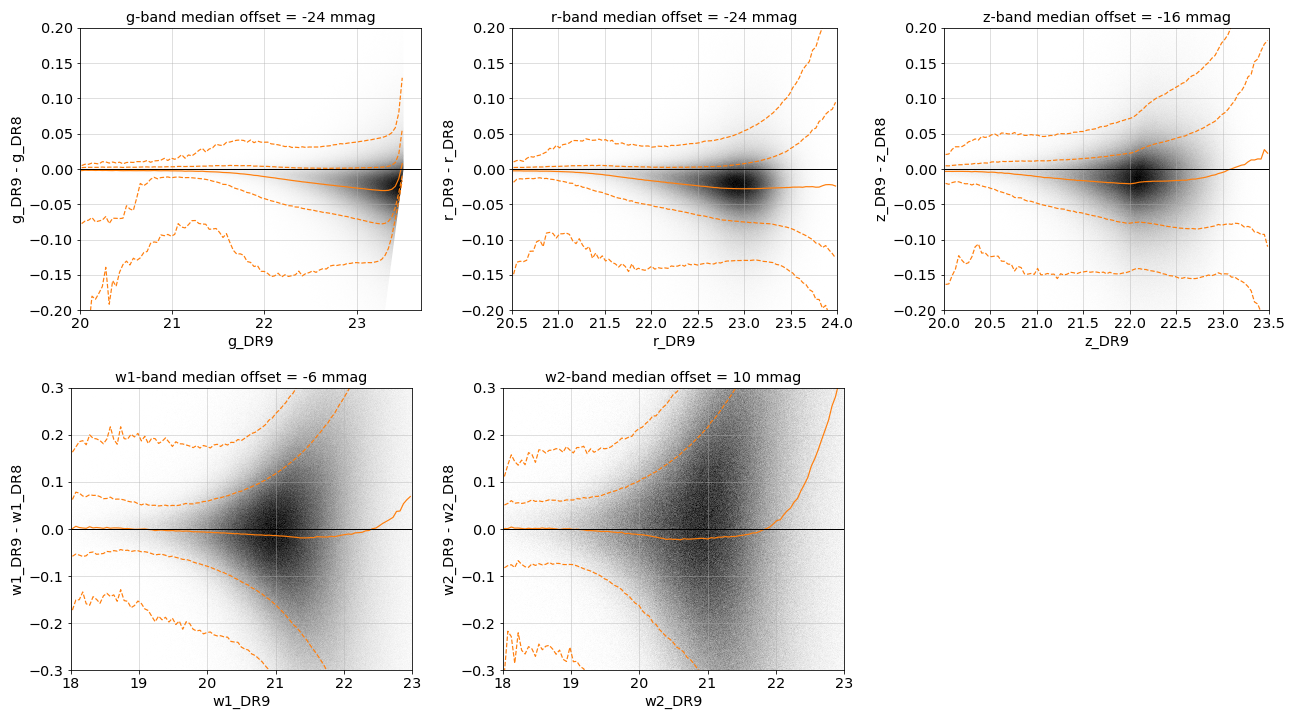

In [15]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[20, 23.7], [20.5, 24], [20, 23.5], [18, 23], [18, 23]]
ylims = [[-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.3, 0.3], [-0.3, 0.3]]
for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = np.isfinite(v)
    median_offset = np.median(v[mask])
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')

__Look at the bright end__

/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in greater
  result = getattr(super(), op)(other)
/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in less
  result = getattr(super(), op)(other)
/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in greater
  result = getattr(super(), op)(other)
/Users/rongpu/miniconda3/lib/python3.7/site-packages/astropy/table/column.py:1020: RuntimeWarning: invalid value encountered in less
  result = getattr(super(), op)(other)


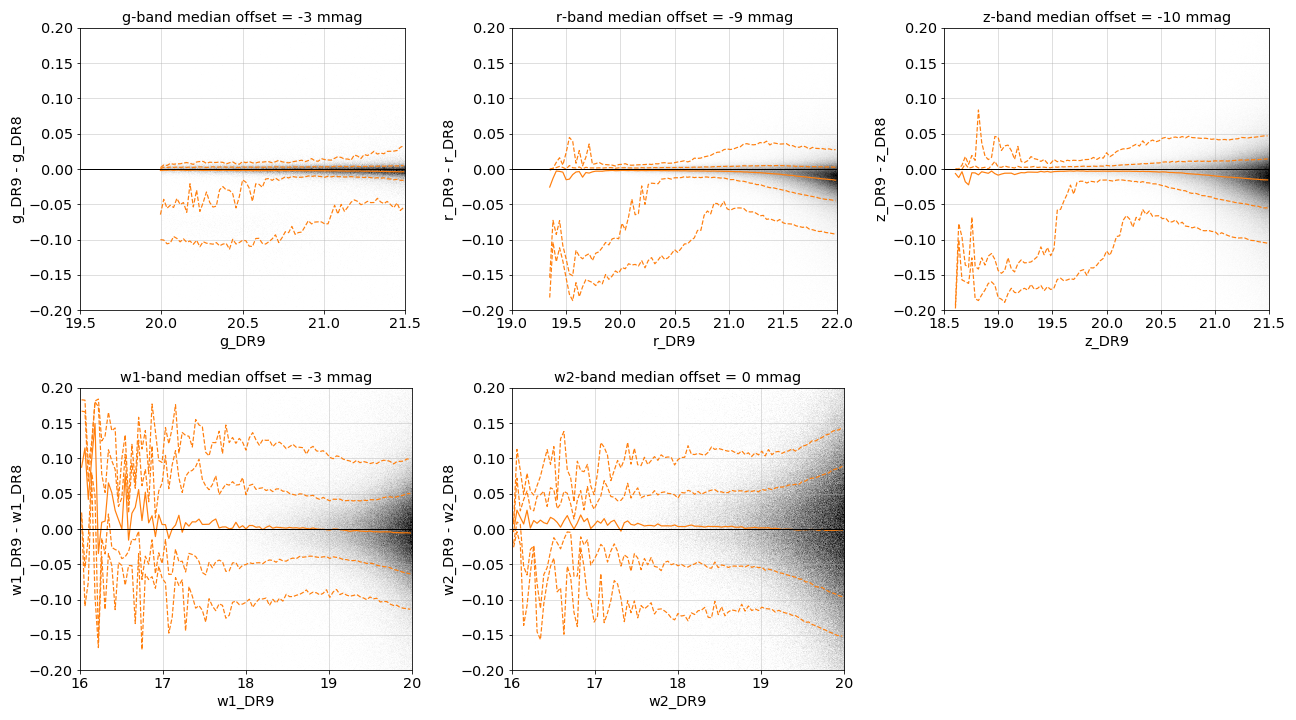

In [16]:
col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[19.5, 21.5], [19., 22], [18.5, 21.5], [16, 20], [16, 20]]
ylims = [[-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2]]
for index in range(len(col_list)):
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = np.isfinite(v)
    mask &= (cat[col]>xmin) & (cat[col]<xmax) & (v>ymin) & (v<ymax)
    median_offset = np.median(v[mask])
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')

__REX objects (in both) only__

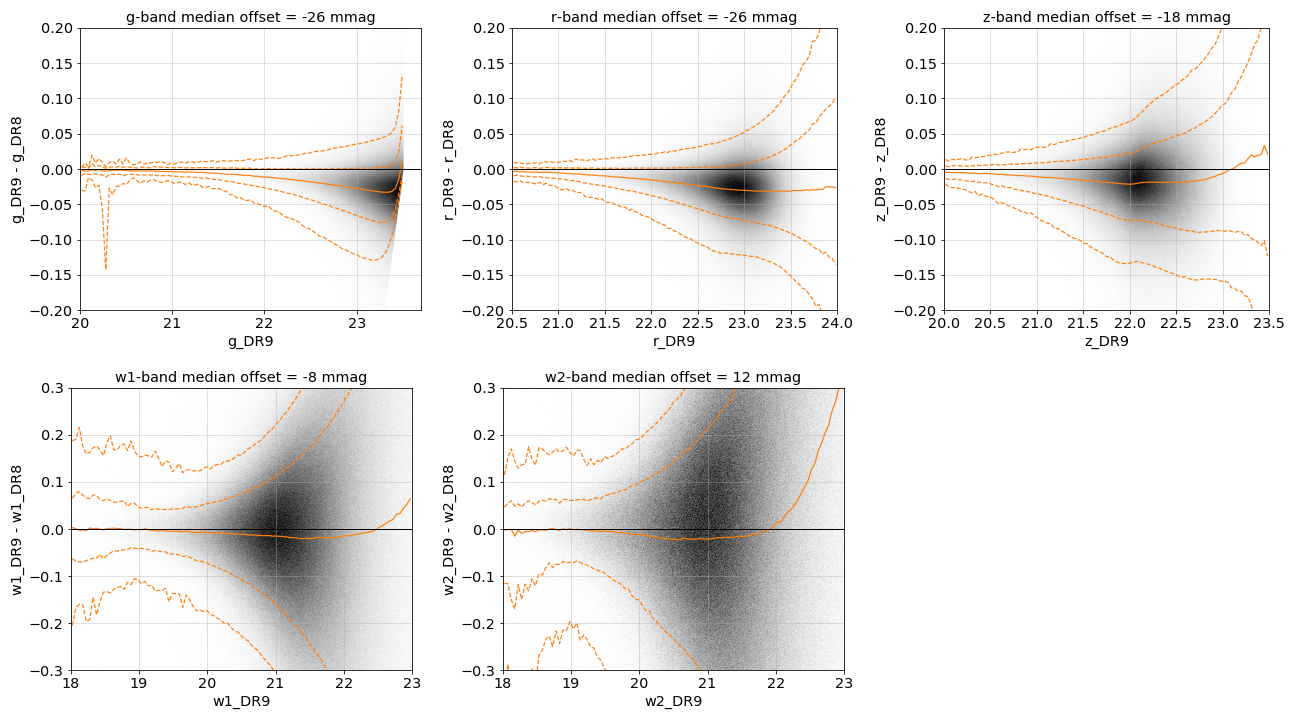

In [17]:
mask0 = (dr8['MORPHTYPE']=='REX') & (cat['MORPHTYPE']=='REX')

col_list = ['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag']
xlims = [[20, 23.7], [20.5, 24], [20, 23.5], [18, 23], [18, 23]]
ylims = [[-0.2, 0.2], [-0.2, 0.2], [-0.2, 0.2], [-0.3, 0.3], [-0.3, 0.3]]
for index in range(len(col_list)):
    col = col_list[index]
    v = cat[col]-dr8[col]
    mask = mask0 & (np.isfinite(v))
    median_offset = np.median(v[mask])
    xmin, xmax, ymin, ymax = xlims[index][0], xlims[index][1], ylims[index][0], ylims[index][1]
    xbins, ybins = np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)
    bin_median, bin_edges, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic='median', bins=xbins)
    bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
    bin_16, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 15.9), bins=xbins)
    bin_84, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 84.1), bins=xbins)
    bin_5, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 5), bins=xbins)
    bin_95, _, _ = stats.binned_statistic(cat[col][mask], v[mask], statistic=lambda y: np.percentile(y, 95), bins=xbins)
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    ########## Simple 2D histogram ###########
    # ax.hist2d(cat[col][mask], v[mask], bins=[xbins, ybins])
    ########## Simple scatter plot ##########
    # plt.plot(cat[col][mask], v[mask], '.', ms=0.1, alpha=0.2)
    ########## Scatter density ##########
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ax.scatter_density(cat[col][mask], v[mask], cmap='gray_r')
    ax.plot(bin_centers, bin_median, color='C1', lw=1.2)
    ax.plot(bin_centers, bin_16, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_84, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_5, 'C1--', lw=1.2)
    ax.plot(bin_centers, bin_95, 'C1--', lw=1.2)
    ax.set_title('{}-band median offset = {:.0f} mmag'.format(col[:-3], median_offset*1000))
    ax.set_ylabel(col[:-3]+'_DR9 - '+col[:-3]+'_DR8')
    ax.set_xlabel(col[:-3]+'_DR9')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.5)
    plt.tight_layout()
    plt.savefig('tmp/{}.png'.format(index+1))
    plt.close()
    
os.system('montage tmp/[1-{}].png -geometry 100% -tile 3x tmp/montage.png'.format(len(col_list)))
Image(filename='tmp/montage.png')